In [127]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [128]:
import cma
import numpy as np
from numbers import Real
import torch
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
import os
import json
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT
from utils.cma import clip_sol


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')
RW_PRIMITIVES_DIR = path.join(CONTENT_DIR, 'rw_primitives')
PRIMITIVE_DIR = path.join(CONTENT_DIR, 'primitives')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
RW_PRIMITIVES_IMGS = get_segment_imgs(RW_PRIMITIVES_DIR, (WIDTH, HEIGHT))
PRIMITIVE_IMGS = get_primitive_imgs(CONTENT_DIR, (WIDTH, HEIGHT))

In [255]:
a = np.array([[0.5, 0.2], [1, 0]])
b = np.array([[0.5, 0.2], [1, 0]]).T

# Normalized
np.linalg.norm(a-b) / len(a)

np.float64(0.5656854249492381)

In [261]:
def loop(es, max_val, primitives_selected, prompt_embedding, predictN, prompt_text, report_interval, x0, gamma=0.4, test=False):
  x0 += 0.5

  # Check if the directory exists
  if not path.exists(path.join(RESULTS_DIR, prompt_text)):
    os.makedirs(path.join(RESULTS_DIR, prompt_text))
  
  with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'w') as f:
    pass # Open to resent the file

  i = 0
  while not es.stop():
      a = time.time()
      solutions = es.ask()
      rasterized_imgs = []
      all_empty_pixels = []
      all_diff = []

      b = time.time()
      for it, solution in enumerate(solutions):
        # Reshape (one for each primitive)
        solution = solution.reshape(-1, predictN)

        # Count how much shapes change from the first solution
        all_diff.append(np.linalg.norm((solution+0.5) - x0) / len(x0))
        assert all_diff[-1] < 1

        solution = clip_sol(solution, max_val)
        

        img = rasterize_shapes(primitives_selected, solution, (WIDTH, HEIGHT))

        # Count empty pixels
        np_img = np.array(img)
        all_empty_pixels.append(np.sum(np_img[:, :, 3] == 0) / (np_img.shape[0] * np_img.shape[1])) # (300, 300, 4) -> 300 * 300 = 90000


        rasterized_imgs.append(Image.alpha_composite(
                                  #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # Blue background
                                  Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                  #Image.new("RGBA", img.size, (0, 0, 0, 0)),  # Black background
                                  img
                              ).convert("RGB"))

      rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 3)
      rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE) # (population_size, 3, 300, 300)
      rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

      sim_loss = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)
      empty_pixel_loss = torch.tensor(all_empty_pixels).to(DEVICE) # (population_size)
      all_diff_loss = torch.tensor(all_diff).to(DEVICE) # (population_size)


      # (1 - cos_similarity) + the count of empty pixels
      losses = (1 - sim_loss) * (1 - gamma) + (1 - all_diff_loss) * gamma + 0.05 * empty_pixel_loss

      es.tell(solutions, [l.item() for l in losses])

      # Save loss info (aka fitness)
      if not test:
        with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'a') as f:
          json.dump({i: {
                          'full_loss': torch.mean(losses).item(),
                          'sim_loss': torch.mean(sim_loss).item(),
                          'pixel_loss': torch.mean(empty_pixel_loss).item(),
                        }
                      }, f)
          f.write('\n')

      
      # Update epoch
      i += 1

      if i % report_interval == 0:
        img = rasterized_imgs[losses.argmax()].cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img_pil = Image.fromarray(img.astype('uint8'), 'RGB')

        # Save best img
        if not test:
          img_pil.save(path.join(RESULTS_DIR, prompt_text, f'epoch_{i}.png'))

        clear_output(wait=True)  # Clear previous output
        display(img_pil)         # Display the new image
        print(f"Epoch {i} - Loss: {sim_loss.max().item()} - Empty pixels: {empty_pixel_loss.min().item()} - All diff: {all_diff_loss.max().item()} - Time: {time.time() - a:.2f}s")
    


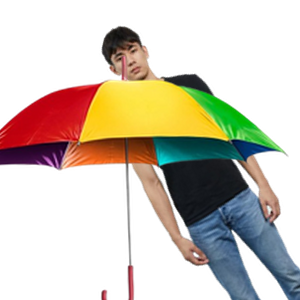

Epoch 154 - Loss: 0.41605129837989807 - Empty pixels: 0.5827777777777777 - All diff: 0.5943455614421742 - Time: 2.42s


KeyboardInterrupt: 

In [262]:

sigma = 0.1
maxiter = 500
popsize = 32
max_val = 0.5
predictN = 5

# Execute the loop for each prompt
for prompt_text, elems in list(RW_PRIMITIVES_IMGS.items())[0:]:
    x0 = np.zeros((len(elems), predictN))
    x0[0, 3] = -0.5 # No rotation

    es = cma.CMAEvolutionStrategy(x0.flatten(), sigma, {
            "maxiter": maxiter,
            "popsize": popsize,
            "bounds": [-max_val, max_val],
    })
    
    
    loop(
        es=es, 
        max_val=max_val,
        primitives_selected=list(elems.values()),
        prompt_embedding=CLIP_emb_from_TEXT(prompt_text),
        predictN=predictN,
        prompt_text=prompt_text,
        report_interval=1,
        x0=x0,
        gamma=0.05,
        test=True
    )

In [232]:
elems

{'person': <PIL.Image.Image image mode=RGBA size=83x300>,
 'umbrella': <PIL.Image.Image image mode=RGBA size=300x214>}